# Student Exam Pass Prediction

## Objective

Build a Machine Learning model that predicts whether a student will pass or fail based on demographic, academic, and social factors from the UCI Student Performance dataset.

# import libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

# Load Dataset and see first 5 rows of the data table

In [4]:
df = pd.read_csv("../data/student-mat.csv", sep=";")
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


# Dataset Overview

In [ ]:
df.shape

In [ ]:
df.columns

In [ ]:
df.info()

In [ ]:
df.describe()

# EDA

### Value Counts

In [ ]:
df["sex"].value_counts(normalize=True)

### Histogram

In [ ]:
df["studytime"].plot(kind="hist", bins=10)
plt.title("Study Time Distribution")
plt.xlabel("Study Time")
plt.ylabel("Frequency")
plt.show()

### Bar chart

In [ ]:
df["sex"].value_counts().sort_index().plot(kind="bar")

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

### Box Plot

In [ ]:
df["age"].plot(kind="box")

plt.title("Age Box Plot")

plt.show()

### Scatter Plot

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(df["G1"],df["G3"])
plt.title("G1 vs Final Grade")
plt.xlabel("G1")    
plt.ylabel("Final Grade")
plt.show()

### Correlation

In [ ]:
df["G1"].corr(df["G3"])

In [ ]:
df.corr(numeric_only=True)

### Heatmap

In [ ]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.show()

# Feature Engineering

In [4]:
df["Pass"] = (df["G3"] >= 10).astype(int)

# Preprocessing

### Encoding

In [5]:
categorical_columns = df.select_dtypes(include="object").columns

df = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True
)

df.head()

C:\Users\AyushiMakwana\AppData\Local\Temp\ipykernel_15328\3649175706.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes
0,18,4,4,2,2,0,4,3,4,1,...,True,False,True,False,False,False,True,True,False,False
1,17,1,1,1,2,0,5,3,3,1,...,False,False,False,True,False,False,False,True,True,False
2,15,1,1,1,2,3,4,3,2,2,...,True,False,True,False,True,False,True,True,True,False
3,15,4,2,1,3,0,3,2,2,1,...,True,False,False,True,True,True,True,True,True,True
4,16,3,3,1,2,0,4,3,2,1,...,False,False,False,True,True,False,True,True,False,False


### Train test split

In [6]:
X = df.drop(["G3", "Pass"], axis=1)
y = df["Pass"]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Scaling

In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model Training

In [9]:
model = LogisticRegression()

In [10]:
model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

# Evaluation

In [11]:
y_pred = model.predict(X_test_scaled)

print("Actual Labels:")
print(y_test.values)

print("\nPredicted Labels:")
print(y_pred)

Actual Labels:
[1 0 1 1 1 1 1 0 1 1 1 0 1 1 0 1 0 0 0 0 1 1 0 1 1 1 1 1 0 0 1 1 0 1 1 0 0
 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 0 1 0 0 0 1 1 1 0 0 1 1 0 1 1 0 1 0 1 1 0
 1 1 0 1 1]

Predicted Labels:
[1 0 1 1 1 1 1 0 1 1 1 0 1 1 0 1 0 0 0 0 1 1 0 1 1 1 1 1 0 0 1 0 0 1 1 0 0
 0 1 0 0 0 1 1 1 0 1 1 1 1 0 1 1 1 0 0 0 1 1 1 1 0 0 0 0 1 1 1 0 1 0 1 1 0
 1 1 0 1 1]


### Confusion Matrix
[[TN FP]
 [FN TP]]

In [14]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[23  3]
 [ 9 44]]


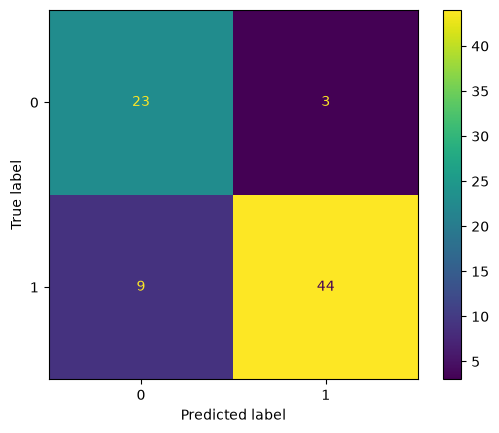

In [15]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

In [ ]:
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.show()

### Accuracy ("How many predictions were correct overall?")

In [17]:
accuracy = accuracy_score(y_test, y_pred)

print(accuracy)
print(f"Accuracy: {accuracy*100:.2f}%")

0.8481012658227848
Accuracy: 84.81%


### Precision ("When a model says a student will pass, how often is it correct?")

In [20]:
precision = precision_score(y_test, y_pred)

print(precision)
print(f"Precision: {precision * 100:.2f}%")

0.9361702127659575
Precision: 93.62%


### Recall ("Show me every student who actually passed.")

In [22]:
recall = recall_score(y_test, y_pred)

print(recall)
print(f"Recall: {recall * 100:.2f}%")

0.8301886792452831
Recall: 83.02%


### F1 score (gets a score considering both precision and recall)

In [12]:
f1 = f1_score(y_test, y_pred)

print(f1)
print(f"F1-score: {f1 * 100:.2f}%")

0.88
F1-score: 88.00%


### ROC and AUC

In [2]:
y_prob = model.predict_proba(X_test)

NameError: name 'model' is not defined

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

In [ ]:
auc = roc_auc_score(y_test, y_prob)

print(auc)

### Cross Validation

In [ ]:
scores = cross_val_score(
    model,
    X_train,
    y_train,
    cv=5
)

In [ ]:
print(scores.mean())

### Grid Seach with cross validation

In [ ]:
## Create the hyperparameter grid.

In [ ]:
param_grid = {
    "C": [0.1, 1, 10, 100],
    "penalty": ["l2"],
    "solver": ["lbfgs"]
}

In [ ]:
## Create Grid Search.

In [ ]:
grid = GridSearchCV(
    estimator=LogisticRegression(),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy"
)

## train grid search

In [ ]:
grid.fit(X_train, y_train)

## find best hyperparameters

In [ ]:
print(grid.best_params_)

## find best score

In [ ]:
print(grid.best_score_)

### Saving the model

In [ ]:
joblib.dump(model, "student_pass_model.pkl")

### Loading model

In [ ]:
loaded_model = joblib.load("student_pass_model.pkl")